# Notebook 04 — Autoencoder Denso

**TFG:** Detección de Anomalías de Consumo Eléctrico en Edge Computing para la Mitigación de Ataques FDI

---

## Objetivo

Entrenar un **Autoencoder denso** (fully-connected) para detección no supervisada de ataques FDI.  
El modelo aprende a reconstruir el perfil normal del consumo; cualquier entrada que se aleje de ese perfil produce un **error de reconstrucción elevado** que se usa como score de anomalía.

### Arquitectura

```
Input (8) → Dense(64) → Dense(32) → Dense(16) → [Bottleneck(8)]
                                                         ↓
Output(8) ← Dense(64) ← Dense(32) ← Dense(16) ←────────┘
```

### Features (8)

| Feature | Descripción |
|---------|-------------|
| 7 sensores base | `Global_active_power` … `Sub_metering_3` |
| `VI_residual` | `GAP − V×I/1000` — inconsistencia física FDI |

### Selección de umbral

Umbral = percentil (100 × (1 − 0.0172)) del MSE en train — calibrado con la tasa de anomalías naturales del EDA.

## 0. Setup

In [1]:
!pip install tensorflow --quiet

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    precision_score, recall_score,
    average_precision_score
)
import time, os, json, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print(f'TensorFlow {tf.__version__}')
print('Setup completo')

TensorFlow 2.20.0
Setup completo


## 1. Carga y Preparación de Datos

In [8]:
BASE_DIR = '/Volumes/Extreme Pro Particion 1TB/TFG/UCIrvine/'

FEATURE_COLS = [
    'Global_active_power', 'Global_reactive_power', 'Voltage',
    'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3'
]

ATTACK_TYPES = [
    'scaling', 'offset', 'noise',
    'ramp', 'pulse', 'step', 'intermittent',
    'replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay',
    'correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'
]

MAX_TRAIN_ROWS = 1_500_000   # ~1 año sintético continuo


def load_synthetic_train(base_dir, max_rows=MAX_TRAIN_ROWS):
    """Carga datos limpios del gemelo digital para entrenamiento."""
    parquet_path = base_dir + 'synthetic_10y_clean.parquet'
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        chunks = []
        for yr in range(2010, 2021):
            p = base_dir + f'synthetic_year_{yr}_clean.csv'
            if os.path.exists(p):
                chunks.append(pd.read_csv(p, index_col='datetime', parse_dates=True))
        if not chunks:
            raise FileNotFoundError(
                'No se encontraron datos del gemelo digital.\n'
                'Ejecuta el notebook 02_Digital_Twin.ipynb primero.'
            )
        df = pd.concat(chunks).sort_index()
    df = df[[c for c in FEATURE_COLS if c in df.columns]].dropna()
    if max_rows and len(df) > max_rows:
        df = df.iloc[:max_rows]
    return df


def load_synthetic_test(base_dir):
    """Carga datos sintéticos con ataques FDI del gemelo digital."""
    parquet_path = base_dir + 'synthetic_10y_with_attacks.parquet'
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
    else:
        chunks = []
        for yr in range(2010, 2021):
            p = base_dir + f'synthetic_year_{yr}_with_attacks.csv'
            if os.path.exists(p):
                chunks.append(pd.read_csv(p, index_col='datetime', parse_dates=True))
        if not chunks:
            raise FileNotFoundError(
                'No se encontraron datos de test con ataques.\n'
                'Ejecuta el notebook 02_Digital_Twin.ipynb primero.'
            )
        df = pd.concat(chunks).sort_index()
    return df


df_train = load_synthetic_train(BASE_DIR)
df_test  = load_synthetic_test(BASE_DIR)
y_test   = df_test['label'].values

print(f'Train (sintético limpio):  {len(df_train):,} filas')
print(f'  Rango: {df_train.index.min().date()} → {df_train.index.max().date()}')
print()
print(f'Test (con 15 tipos FDI):  {len(df_test):,} filas')
print(f'  Rango: {df_test.index.min().date()} → {df_test.index.max().date()}')
print(f'  Ataques: {y_test.sum():,} ({y_test.mean()*100:.2f}%)')
print()
print('Distribución de ataques por tipo:')
vc = df_test[df_test['label'] == 1]['attack_type'].value_counts()
for t, c in vc.items():
    print(f'  {t:25s}: {c:>8,}')

Train (sintético limpio):  1,500,000 filas
  Rango: 2010-12-01 → 2013-10-07

Test (con 15 tipos FDI):  5,260,320 filas
  Rango: 2010-12-01 → 2020-11-30
  Ataques: 19,877 (0.38%)

Distribución de ataques por tipo:
  noise                    :    1,684
  voltage_spoof            :    1,635
  smooth_decay             :    1,551
  replay                   :    1,445
  pulse                    :    1,381
  seasonal_swap            :    1,369
  intermittent             :    1,363
  step                     :    1,332
  scaling                  :    1,298
  adversarial              :    1,244
  ramp                     :    1,228
  load_shift               :    1,222
  offset                   :    1,144
  correlated_scaling       :    1,136
  weekend_mimicry          :      845


In [9]:
def get_features(df):
    """8 features: 7 sensores + residual fisico VI."""
    f = df[FEATURE_COLS].copy()
    f['VI_residual'] = (
        df['Global_active_power']
        - df['Voltage'] * df['Global_intensity'] / 1000.0
    )
    return f.values, f.columns.tolist()


X_train_raw, feat_names = get_features(df_train)
X_test_raw,  _          = get_features(df_test)

# MinMaxScaler ajustado solo sobre train (sin data leakage)
scaler  = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

# Eliminar NaN
X_train = np.nan_to_num(X_train, nan=0.0)
X_test  = np.nan_to_num(X_test,  nan=0.0)

n_features = X_train.shape[1]

print(f'Features ({n_features}): {feat_names}')
print(f'X_train: {X_train.shape}  |  X_test: {X_test.shape}')

Features (8): ['Global_active_power', 'Global_reactive_power', 'Voltage', 'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3', 'VI_residual']
X_train: (1500000, 8)  |  X_test: (5260320, 8)


## 2. Arquitectura del Autoencoder Denso

Diseño simétrico con cuello de botella de 8 dimensiones (mismo número que features de entrada).  
Activación ReLU en capas intermedias; capa de salida lineal para permitir reconstrucción de valores escalados en [0, 1].

In [10]:
def build_dense_autoencoder(n_features, enc_dim=8):
    inp = Input(shape=(n_features,), name='input')

    # Encoder
    x = Dense(64, activation='relu', name='enc1')(inp)
    x = Dense(32, activation='relu', name='enc2')(x)
    x = Dense(16, activation='relu', name='enc3')(x)
    encoded = Dense(enc_dim, activation='relu', name='bottleneck')(x)

    # Decoder
    x = Dense(16, activation='relu', name='dec1')(encoded)
    x = Dense(32, activation='relu', name='dec2')(x)
    x = Dense(64, activation='relu', name='dec3')(x)
    decoded = Dense(n_features, activation='linear', name='output')(x)

    model = Model(inp, decoded, name='dense_autoencoder')
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='mse'
    )
    return model


ae = build_dense_autoencoder(n_features)
ae.summary()

print(f'\nParametros entrenables: {ae.count_params():,}')

Model: "dense_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc1 (Dense)                    │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc2 (Dense)                    │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ enc3 (Dense)                    │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec1 (Dense)                    │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec2 (Dense)                    │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dec3 (Dense)                    │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,640 (25.94 KB)

 Trainable params: 6,640 (25.94 KB)

 Non-trainable params: 0 (0.00 B)


Parametros entrenables: 6,640


## 3. Entrenamiento

In [11]:
callbacks = [
    EarlyStopping(
        monitor='val_loss', patience=10,
        restore_best_weights=True, verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5,
        patience=5, min_lr=1e-6, verbose=1
    )
]

t0 = time.time()
history = ae.fit(
    X_train, X_train,          # target = input (autoencoder)
    epochs=100,
    batch_size=2048,
    validation_split=0.1,
    callbacks=callbacks,
    verbose=1
)
t_train = time.time() - t0

print(f'\nEntrenamiento: {t_train:.1f} s  |  {len(history.history["loss"])} epocas')

Epoch 1/100
660/660 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0061 - val_loss: 1.8922e-04 - learning_rate: 0.0010
Epoch 2/100
660/660 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 7.6836e-05 - val_loss: 2.6647e-06 - learning_rate: 0.0010
Epoch 3/100
660/660 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.7532e-06 - val_loss: 1.5289e-06 - learning_rate: 0.0010
Epoch 4/100
660/660 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 6.5835e-06 - val_loss: 4.3712e-06 - learning_rate: 0.0010
Epoch 5/100
660/660 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.6509e-06 - val_loss: 7.4146e-07 - learning_rate: 0.0010
Epoch 6/100
660/660 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 5.4012e-06 - val_loss: 1.6495e-05 - learning_rate: 0.0010
Epoch 7/100
639/660 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.2466e-06
Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
660/660 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 6.3613e-06 - val_loss: 2.0474e-06 - learning_rate: 0.0010
Epoch 8/100
660/660 ━━━━━━━━━━━━━━━

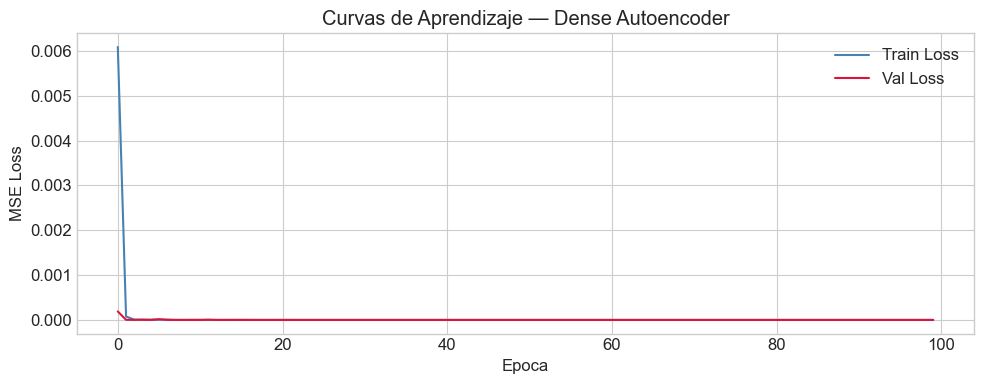

Mejor val_loss: 0.000000


In [12]:
# Curvas de aprendizaje
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(history.history['loss'],     color='steelblue', label='Train Loss')
ax.plot(history.history['val_loss'], color='crimson',   label='Val Loss')
ax.set(xlabel='Epoca', ylabel='MSE Loss',
       title='Curvas de Aprendizaje — Dense Autoencoder')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Mejor val_loss: {min(history.history["val_loss"]):.6f}')

## 4. Selección de Umbral y Evaluación

El umbral se calibra sobre los datos de train (limpios): se elige el percentil que corresponde a la tasa de anomalías naturales medida en el EDA (**1.72%**).  
Esto garantiza que el modelo no etiqueta más del 1.72% de los datos normales como ataques.

Distribucion MSE en train (datos limpios):
  Media:    0.000000
  Std:      0.000002
  P50:      0.000000
  Umbral:   0.000001  (FPR objetivo = 1.72%)


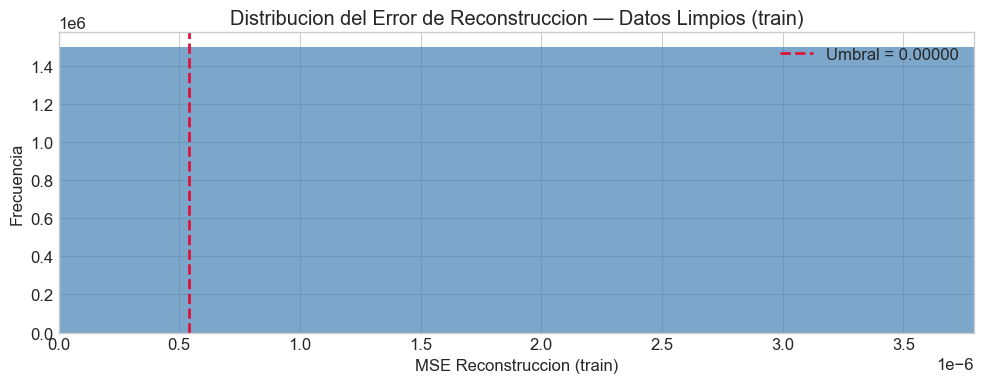

In [13]:
# Error de reconstruccion sobre train
train_recon = ae.predict(X_train, batch_size=4096, verbose=0)
train_mse   = np.mean((X_train - train_recon) ** 2, axis=1)

TARGET_FPR = 0.0172
threshold  = float(np.percentile(train_mse, 100 * (1 - TARGET_FPR)))

print('Distribucion MSE en train (datos limpios):')
print(f'  Media:    {train_mse.mean():.6f}')
print(f'  Std:      {train_mse.std():.6f}')
print(f'  P50:      {np.percentile(train_mse, 50):.6f}')
print(f'  Umbral:   {threshold:.6f}  (FPR objetivo = {TARGET_FPR*100:.2f}%)')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(train_mse, bins=200, color='steelblue', alpha=0.7)
ax.axvline(threshold, color='crimson', linestyle='--', lw=2,
           label=f'Umbral = {threshold:.5f}')
ax.set(xlabel='MSE Reconstruccion (train)',
       ylabel='Frecuencia',
       title='Distribucion del Error de Reconstruccion — Datos Limpios (train)')
ax.set_xlim(0, np.percentile(train_mse, 99.9))
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Inferencia sobre test
_ = ae.predict(X_test[:100], batch_size=100, verbose=0)   # warmup
t0 = time.time()
test_recon = ae.predict(X_test, batch_size=4096, verbose=0)
t_inf = time.time() - t0

test_mse   = np.mean((X_test - test_recon) ** 2, axis=1)
y_pred_ae  = (test_mse > threshold).astype(int)

ms_sample = t_inf / len(X_test) * 1000

print(f'Inferencia: {t_inf*1000:.0f} ms total  |  {ms_sample:.4f} ms/muestra')
print()
print('=' * 55)
print('METRICAS DE EVALUACION — DENSE AUTOENCODER')
print('=' * 55)
print()
print(classification_report(y_test, y_pred_ae,
                            target_names=['Normal', 'Ataque']))

f1_val  = f1_score(y_test, y_pred_ae)
prec    = precision_score(y_test, y_pred_ae)
rec     = recall_score(y_test, y_pred_ae)
auc_roc = roc_auc_score(y_test, test_mse)
auc_pr  = average_precision_score(y_test, test_mse)

print(f'AUC-ROC: {auc_roc:.4f}  |  AUC-PR: {auc_pr:.4f}')

Inferencia: 5672 ms total  |  0.0011 ms/muestra

METRICAS DE EVALUACION — DENSE AUTOENCODER

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99   5240443
      Ataque       0.11      0.68      0.19     19877

    accuracy                           0.98   5260320
   macro avg       0.55      0.83      0.59   5260320
weighted avg       1.00      0.98      0.99   5260320

AUC-ROC: 0.8292  |  AUC-PR: 0.6816


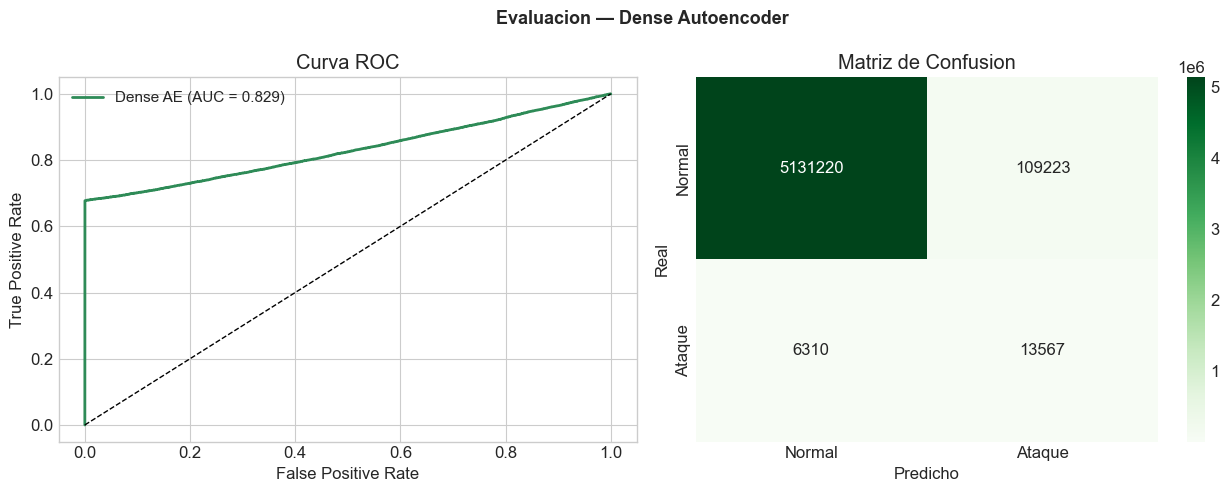

In [15]:
# ROC + Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, test_mse)
axes[0].plot(fpr, tpr, color='seagreen', lw=2,
             label=f'Dense AE (AUC = {auc_roc:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1)
axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
            title='Curva ROC')
axes[0].legend(fontsize=11)

cm = confusion_matrix(y_test, y_pred_ae)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Normal', 'Ataque'],
            yticklabels=['Normal', 'Ataque'])
axes[1].set(xlabel='Predicho', ylabel='Real', title='Matriz de Confusion')

plt.suptitle('Evaluacion — Dense Autoencoder', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Recall por tipo de ataque FDI:
  Categoría     Tipo                         N filas   Detectadas    Recall
  Básicos       scaling                        1,298        1,135     0.874
  Básicos       offset                         1,144          940     0.822
  Básicos       noise                          1,684        1,605     0.953

  Temporales    ramp                           1,228        1,092     0.889
  Temporales    pulse                          1,381          265     0.192
  Temporales    step                           1,332        1,145     0.860
  Temporales    intermittent                   1,363          609     0.447

  Patrón        replay                         1,445        1,445     1.000
  Patrón        weekend_mimicry                  845          845     1.000
  Patrón        seasonal_swap                  1,369        1,347     0.984
  Patrón        smooth_decay                   1,551        1,310     0.845

  Capa Física   correlated_scaling             1,136  

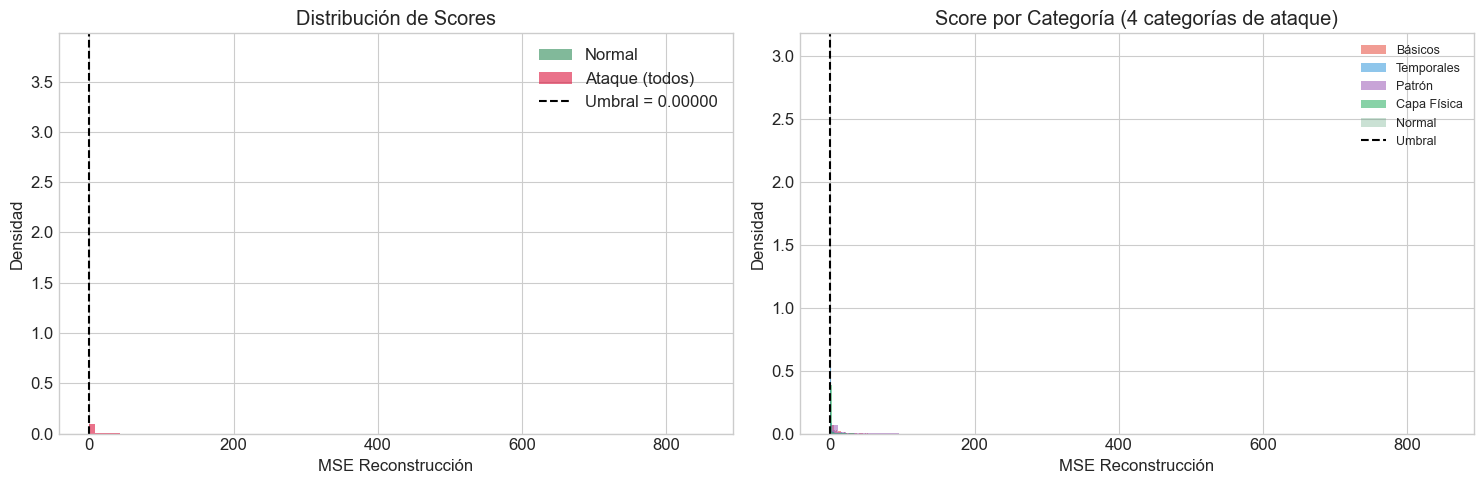

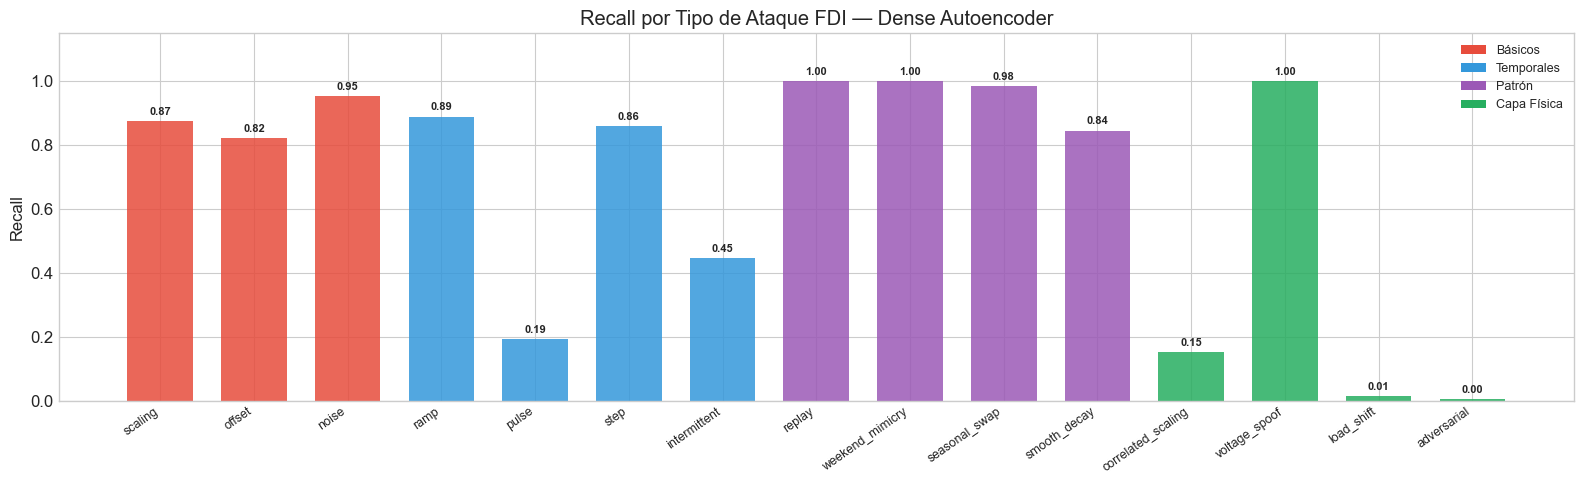

In [16]:
# Recall por tipo de ataque (los 15 tipos del gemelo digital)
CATEGORIES = {
    'Básicos':     ['scaling', 'offset', 'noise'],
    'Temporales':  ['ramp', 'pulse', 'step', 'intermittent'],
    'Patrón':      ['replay', 'weekend_mimicry', 'seasonal_swap', 'smooth_decay'],
    'Capa Física': ['correlated_scaling', 'voltage_spoof', 'load_shift', 'adversarial'],
}
CAT_COLORS = {
    'Básicos': '#e74c3c', 'Temporales': '#3498db',
    'Patrón': '#9b59b6', 'Capa Física': '#27ae60'
}

print('Recall por tipo de ataque FDI:')
print(f'  {"Categoría":12s}  {"Tipo":25s}  {"N filas":>9s}  {"Detectadas":>11s}  {"Recall":>8s}')
for cat, types in CATEGORIES.items():
    for t in types:
        mask = (df_test['attack_type'] == t).values
        n_t  = mask.sum()
        if n_t == 0:
            continue
        det = (y_pred_ae[mask] == 1).sum()
        print(f'  {cat:12s}  {t:25s}  {n_t:>9,}  {det:>11,}  {det/n_t:>8.3f}')
    print()

# Score distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(test_mse[y_test == 0], bins=100, alpha=0.6,
             color='seagreen', label='Normal', density=True)
axes[0].hist(test_mse[y_test == 1], bins=100, alpha=0.6,
             color='crimson', label='Ataque (todos)', density=True)
axes[0].axvline(threshold, color='k', linestyle='--', lw=1.5,
                label=f'Umbral = {threshold:.5f}')
axes[0].set(xlabel='MSE Reconstrucción', ylabel='Densidad',
            title='Distribución de Scores')
axes[0].legend()

# Por categoría
for cat, types in CATEGORIES.items():
    cat_mask = np.isin(df_test['attack_type'].values, types)
    if cat_mask.sum() > 0:
        axes[1].hist(test_mse[cat_mask], bins=80, alpha=0.55,
                     color=CAT_COLORS[cat], label=cat, density=True)
axes[1].hist(test_mse[y_test == 0], bins=80, alpha=0.25,
             color='seagreen', label='Normal', density=True)
axes[1].axvline(threshold, color='k', linestyle='--', lw=1.5, label='Umbral')
axes[1].set(xlabel='MSE Reconstrucción', ylabel='Densidad',
            title='Score por Categoría (4 categorías de ataque)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

# Gráfico de barras: recall por tipo
all_types = [t for types in CATEGORIES.values() for t in types]
recall_vals = []
colors_bar  = []
for cat, types in CATEGORIES.items():
    for t in types:
        mask = (df_test['attack_type'] == t).values
        n_t  = mask.sum()
        r    = (y_pred_ae[mask] == 1).sum() / n_t if n_t > 0 else 0
        recall_vals.append(r)
        colors_bar.append(CAT_COLORS[cat])

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(all_types, recall_vals, color=colors_bar, alpha=0.85, width=0.7)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Recall')
ax.set_title('Recall por Tipo de Ataque FDI — Dense Autoencoder')
ax.set_xticklabels(all_types, rotation=35, ha='right', fontsize=9)
for bar, val in zip(bars, recall_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=8, fontweight='bold')
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=c, label=cat) for cat, c in CAT_COLORS.items()]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

## 5. Análisis Edge Computing

In [17]:
print('=' * 50)
print('ANALISIS EDGE COMPUTING — DENSE AUTOENCODER')
print('=' * 50)

# Guardar modelo
model_path = BASE_DIR + 'model_dense_autoencoder.keras'
try:
    ae.save(model_path)
except Exception:
    # Fallback para versiones antiguas de TF
    model_path = BASE_DIR + 'model_dense_autoencoder.h5'
    ae.save(model_path)

size_kb = os.path.getsize(model_path) / 1e3

# Timing preciso
times = []
for _ in range(3):
    t0 = time.time()
    ae.predict(X_test, batch_size=4096, verbose=0)
    times.append(time.time() - t0)
ms_avg = np.mean(times) / len(X_test) * 1000

print(f'Parametros entrenables:  {ae.count_params():,}')
print(f'Tamano en disco:         {size_kb:.1f} KB')
print(f'Latencia inferencia:     {ms_avg:.4f} ms/muestra')
print(f'Throughput:              {1000/ms_avg:.0f} muestras/s')
print(f'Tiempo entrenamiento:    {t_train:.1f} s')

# Guardar umbral
np.save(BASE_DIR + 'threshold_dense_ae.npy', np.array([threshold]))

# Guardar predicciones
df_out = df_test.copy()
df_out['dae_score'] = test_mse
df_out['dae_pred']  = y_pred_ae
df_out.to_csv(BASE_DIR + 'predictions_dense_autoencoder.csv')
print(f'\nPredicciones guardadas: predictions_dense_autoencoder.csv')

metrics_dae = {
    'model':          'Dense Autoencoder',
    'f1':             round(f1_val, 4),
    'precision':      round(prec, 4),
    'recall':         round(rec, 4),
    'auc_roc':        round(auc_roc, 4),
    'auc_pr':         round(auc_pr, 4),
    'model_size_kb':  round(size_kb, 1),
    'ms_per_sample':  round(ms_avg, 4),
    'n_params':       ae.count_params(),
    'n_features':     n_features,
    'train_time_s':   round(t_train, 1),
    'granularity':    '1 min',
    'threshold':      round(threshold, 8),
    'enc_dim':        8
}
with open(BASE_DIR + 'metrics_dense_autoencoder.json', 'w') as fh:
    json.dump(metrics_dae, fh, indent=2)

print(f'Metricas guardadas: metrics_dense_autoencoder.json')
for k, v in metrics_dae.items():
    print(f'  {k}: {v}')

ANALISIS EDGE COMPUTING — DENSE AUTOENCODER
Parametros entrenables:  6,640
Tamano en disco:         133.6 KB
Latencia inferencia:     0.0003 ms/muestra
Throughput:              3811923 muestras/s
Tiempo entrenamiento:    156.2 s

Predicciones guardadas: predictions_dense_autoencoder.csv
Metricas guardadas: metrics_dense_autoencoder.json
  model: Dense Autoencoder
  f1: 0.1902
  precision: 0.1105
  recall: 0.6825
  auc_roc: 0.8292
  auc_pr: 0.6816
  model_size_kb: 133.6
  ms_per_sample: 0.0003
  n_params: 6640
  n_features: 8
  train_time_s: 156.2
  granularity: 1 min
  threshold: 5.4e-07
  enc_dim: 8


## 6. Resumen

### Interpretación del Dense Autoencoder

- El AE aprende el **manifold de normalidad** en el espacio de 8 features
- Las filas normales se reconstruyen con MSE bajo; las atacadas producen error elevado
- El **VI_residual** es la feature más informativa: bajo ataque scaling/offset, cambia sustancialmente respecto al patrón aprendido en train
- El AE no tiene memoria temporal — opera por timestep individual (igual que el IF)

### Limitaciones

- No captura dependencias temporales (correlaciones entre timesteps consecutivos)
- Sensible a la escala: requiere el mismo scaler que se ajustó en train
- Ataques de ruido siguen siendo difíciles: el AE puede reconstruir ruido si la amplitud está dentro del rango normal

### Comparación esperada con Notebook 05 (LSTM-AE)

El LSTM-AE debería mejorar el recall en ataques de **scaling** y **offset** que imitan patrones normales de consumo, ya que el contexto temporal permite detectar inconsistencias en la dinámica de la señal.